# Glitch inference across duration and SNR

The joint analysis in the paper rests on **one** glitch at **one** working point
($\tau = 300\,$s, $\rho_{\rm gl} = 42.7$) and **one** noise realisation. Two questions
follow from that, and this notebook answers both with the same set of runs.

**1. Is $\tau = 300\,$s a "short" glitch, and does duration help or hurt?**
The damping time sets the spectral knee $f_{\rm knee} = 1/2\pi\tau$, which decides how
much glitch power lands inside the $3\,$mHz analysis band and how sharply the broken
power law of the waveform is resolved. So "short" and "long" are statements about the
knee, not about the amplitude — which is why $\Delta v$ is rescaled at every $\tau$ to
hold the optimal SNR fixed. Without that rescaling one measures only the trivial fact
that a glitch with less in-band power is harder to measure.

**2. Are the quoted credible intervals the true scatter?**
A single realisation cannot say. Each configuration is repeated over independent noise
draws and what is recorded per realisation is the standardised offset
$$z_i = \frac{\text{median}_i - \theta_i^{\rm true}}{\sigma_i},$$
whose spread across realisations is the honest answer: $\mathrm{std}(z) = 1$ means the
error bars *are* the scatter, $\mathrm{std}(z) > 1$ means they are optimistic.

**Grid.** $\tau \in \{100, 300, 3000\}\,$s (knee at $1.6$, $0.53$, $0.053\,$mHz — near
the top of the band, the fiducial, near the bottom) $\times$ $\rho \in \{15, 42.7,
150\}$ (below, at, and well above the resolvability boundary discussed by
Muratore et al. 2025 and Pozzoli et al. 2026). The centre cell is the paper's fiducial
glitch, so the grid *extends* the published working point rather than replacing it.

**Scope.** Glitch only — no Galactic binary. That isolates the duration/SNR scaling
from the source-confusion question, which the `glitch_GB/` notebooks handle.
The heavy lifting is in `glitch_comparison.py`; this notebook drives it and reports.

In [1]:
import os
# The likelihood is cheap and the grid is embarrassingly parallel, so this study runs
# on CPU workers. It also keeps the GPU free for the joint-analysis notebooks.
os.environ["JAX_PLATFORMS"] = "cpu"

import sys
import numpy as np
import jax, jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath(".."))                 # noise.py
sys.path.insert(0, os.path.abspath("../../paper/validation"))   # _style.py

import jaxglitches as jg
import noise as ns
import glitch_comparison as gc
from _style import C, COL_IN, FULL_IN, save

import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=False)
print("taus", gc.TAUS, " rhos", gc.RHOS)

taus (100.0, 300.0, 3000.0)  rhos (15.0, 42.7, 150.0)


## 1. Where the fiducial glitch sits in the LPF population

The claim to test first is whether $\tau = 300\,$s is *short*. It is short compared
with an MBHB inspiral, which lasts weeks; it is not short compared with an LPF glitch.
The bundled catalogue is the one the priors and `catalog_generator.py` are drawn from
(Baghi et al. 2022, ordinary runs).

In [2]:
cat = np.loadtxt(os.path.join(os.path.dirname(jg.__file__), "lpf_data",
                              "2021-09-17-effective_glitch_parameters_ordinary.txt"),
                 comments="#")
tau_lpf, dv_lpf = cat[:, 0], np.abs(cat[:, 1])
print(f"LPF ordinary-run catalogue: {len(tau_lpf)} events")
print(f"  median tau                 = {np.median(tau_lpf):.3g} s")
print(f"  quantiles of tau (50/75/90/95/99) = "
      + ", ".join(f"{np.quantile(tau_lpf, q):.3g}" for q in (.5, .75, .9, .95, .99)) + " s")
for t in (100.0, 300.0, 3000.0):
    print(f"  tau = {t:6.0f} s  ->  percentile {100*(tau_lpf < t).mean():5.1f} "
          f"({100*(tau_lpf >= t).mean():4.1f}% of events are longer),  "
          f"f_knee = {1/(2*np.pi*t):.3g} Hz")

# the knee has to be inside the band for tau to be measurable at all (Sec. "knee")
tau_band = 1.0 / (2 * np.pi * 3e-3)
print(f"\nknee inside f < 3 mHz requires tau > {tau_band:.1f} s: "
      f"{100*(tau_lpf > tau_band).mean():.1f}% of the LPF catalogue")
print(f"median |Deltav| = {np.median(dv_lpf):.3g} m/s, "
      f"loudest = {dv_lpf.max():.3g} m/s")

LPF ordinary-run catalogue: 377 events
  median tau                 = 0.446 s
  quantiles of tau (50/75/90/95/99) = 0.446, 17.2, 33.5, 848, 5e+04 s
  tau =    100 s  ->  percentile  92.8 ( 7.2% of events are longer),  f_knee = 0.00159 Hz
  tau =    300 s  ->  percentile  93.9 ( 6.1% of events are longer),  f_knee = 0.000531 Hz
  tau =   3000 s  ->  percentile  97.6 ( 2.4% of events are longer),  f_knee = 5.31e-05 Hz

knee inside f < 3 mHz requires tau > 53.1 s: 8.2% of the LPF catalogue
median |Deltav| = 3.05e-13 m/s, loudest = 2.15e-08 m/s


## 2. The analysis grid, and why a shorter segment is not an approximation

The study below runs on a segment 16 times shorter than the paper's year, at the same
sampling step. That is not a shortcut with a cost: the optimal SNR and the Fisher widths
are integrals,
$$\rho^2 = 4\int |h|^2/S\,\mathrm{d}f, \qquad
  \Gamma_{ij} = 4\,\mathrm{Re}\!\int \partial_i h^* \partial_j h / S\,\mathrm{d}f,$$
so shortening the segment only coarsens the Riemann sum and raises $f_{\min}$ from
$3.2\times10^{-8}$ to $5.1\times10^{-7}\,$Hz — a region where the steeply rising
acceleration PSD leaves the glitch no measurable power. The cell below checks it rather
than asserting it.

In [3]:
def fisher_widths(N, tau, rho=42.7):
    fr = jnp.asarray(np.fft.rfftfreq(N, gc.DT))
    T = N * gc.DT
    S = ns.psd_tdi1_array(jnp.where(fr > 0, fr, 1.0), t_obs=T)
    h = jg.clean_signal_f(jnp.array([gc.T0_TRUE, 1e-11, tau]), fr,
                          T=jg.T_ARM_s, tdi=1).at[0].set(0 + 0j)
    dv = 1e-11 * rho / float(jg.snr(h, S))
    G = np.asarray(jg.fisher_matrix(jnp.array([gc.T0_TRUE, dv, tau]), fr, S,
                                    T=jg.T_ARM_s, tdi=1))
    sd = np.sqrt(np.diag(np.linalg.inv(G)))
    return np.array([dv, sd[0], sd[1] / dv, sd[2] / tau])

N_YEAR = 187392
print(f"full year: N={N_YEAR}, T={N_YEAR*gc.DT:.4g} s, f_min={1/(N_YEAR*gc.DT):.2e} Hz")
print(f"this study: N={gc.N_SAMP}, T={gc.N_SAMP*gc.DT:.4g} s, "
      f"f_min={1/(gc.N_SAMP*gc.DT):.2e} Hz\n")
print(f"{'tau [s]':>8}  {'quantity':<14}{'full year':>13}{'short segment':>15}{'rel. diff':>12}")
for tau in gc.TAUS:
    a, b = fisher_widths(N_YEAR, tau), fisher_widths(gc.N_SAMP, tau)
    for q, (x, y) in zip(("Deltav [m/s]", "sigma_t0 [s]", "sigma_dv/dv",
                          "sigma_tau/tau"), zip(a, b)):
        print(f"{tau:8.0f}  {q:<14}{x:13.6g}{y:15.6g}{(y/x - 1):12.1e}")

full year: N=187392, T=3.123e+07 s, f_min=3.20e-08 Hz
this study: N=11712, T=1.952e+06 s, f_min=5.12e-07 Hz

 tau [s]  quantity          full year  short segment   rel. diff


     100  Deltav [m/s]    4.40167e-12    4.40165e-12    -4.6e-06
     100  sigma_t0 [s]        5.57639         5.5761    -5.2e-05
     100  sigma_dv/dv       0.0360859      0.0360855    -1.0e-05
     100  sigma_tau/tau     0.0470471      0.0470455    -3.3e-05
     300  Deltav [m/s]    1.00014e-11    1.00014e-11    -4.5e-07
     300  sigma_t0 [s]        7.49536        7.49525    -1.5e-05
     300  sigma_dv/dv       0.0376057      0.0376056    -3.5e-06
     300  sigma_tau/tau     0.0327049      0.0327047    -6.7e-06
    3000  Deltav [m/s]    1.48053e-10    1.48053e-10    -1.1e-08
    3000  sigma_t0 [s]        21.0309        21.0309    -3.0e-06
    3000  sigma_dv/dv       0.0446435      0.0446435    -3.5e-07
    3000  sigma_tau/tau     0.0276414      0.0276414    -4.9e-07


Every column agrees to better than $10^{-4}$ relative, so the shorter segment carries the
same information about the glitch and the likelihood costs 16 times less. What *does*
change is the noise draw — which is the point of averaging over realisations.

## 3. Fisher scan: precision against duration at fixed SNR

Before spending any MCMC, the continuous version of the question. $\Delta v$ is set at
each $\tau$ so that the optimal SNR is exactly $42.7$, and the Fisher matrix is
evaluated at the truth. This is deterministic and takes seconds; it says which way the
duration dependence points, and the MCMC grid below then confirms it and adds the
realisation scatter that Fisher cannot see.

In [4]:
freq = jnp.asarray(np.fft.rfftfreq(gc.N_SAMP, gc.DT))
T_OBS = gc.N_SAMP * gc.DT
psd = ns.psd_tdi1_array(jnp.where(freq > 0, freq, 1.0), t_obs=T_OBS)
print(f"T_obs = {T_OBS:.4g} s, {len(freq)} bins up to {float(freq[-1])*1e3:.1f} mHz")

def dv_for_snr(tau, rho):
    # Deltav giving optimal SNR `rho` at this tau -- rho is linear in Deltav
    h = jg.clean_signal_f(jnp.array([gc.T0_TRUE, 1e-11, tau]), freq,
                          T=jg.T_ARM_s, tdi=1).at[0].set(0 + 0j)
    return 1e-11 * rho / float(jg.snr(h, psd))

tau_scan = np.geomspace(3.0, 3e4, 40)
fish = []
for t in tau_scan:
    dv = dv_for_snr(t, 42.7)
    G = np.asarray(jg.fisher_matrix(jnp.array([gc.T0_TRUE, dv, t]), freq, psd,
                                    T=jg.T_ARM_s, tdi=1))
    s = np.sqrt(np.diag(np.linalg.inv(G)))
    fish.append([s[0], s[1] / dv, s[2] / t])
fish = np.array(fish)                     # sigma_t0 [s], sigma_dv/dv, sigma_tau/tau

for t in (30., 100., 300., 1000., 3000., 1e4):
    dv = dv_for_snr(t, 42.7)
    G = np.asarray(jg.fisher_matrix(jnp.array([gc.T0_TRUE, dv, t]), freq, psd,
                                    T=jg.T_ARM_s, tdi=1))
    s = np.sqrt(np.diag(np.linalg.inv(G)))
    print(f"tau={t:7.0f}s  f_knee={1/(2*np.pi*t):8.2e} Hz  Deltav(rho=42.7)={dv:9.3e} m/s"
          f"   sigma_t0={s[0]:6.2f} s   sigma_dv/dv={s[1]/dv:7.4f}   sigma_tau/tau={s[2]/t:7.4f}")

T_obs = 1.952e+06 s, 5857 bins up to 3.0 mHz


tau=     30s  f_knee=5.31e-03 Hz  Deltav(rho=42.7)=2.819e-12 m/s   sigma_t0=  9.05 s   sigma_dv/dv= 0.0372   sigma_tau/tau= 0.1701
tau=    100s  f_knee=1.59e-03 Hz  Deltav(rho=42.7)=4.402e-12 m/s   sigma_t0=  5.58 s   sigma_dv/dv= 0.0361   sigma_tau/tau= 0.0470
tau=    300s  f_knee=5.31e-04 Hz  Deltav(rho=42.7)=1.000e-11 m/s   sigma_t0=  7.50 s   sigma_dv/dv= 0.0376   sigma_tau/tau= 0.0327
tau=   1000s  f_knee=1.59e-04 Hz  Deltav(rho=42.7)=3.562e-11 m/s   sigma_t0= 12.86 s   sigma_dv/dv= 0.0417   sigma_tau/tau= 0.0288
tau=   3000s  f_knee=5.31e-05 Hz  Deltav(rho=42.7)=1.481e-10 m/s   sigma_t0= 21.03 s   sigma_dv/dv= 0.0446   sigma_tau/tau= 0.0276
tau=  10000s  f_knee=1.59e-05 Hz  Deltav(rho=42.7)=8.222e-10 m/s   sigma_t0= 36.83 s   sigma_dv/dv= 0.0461   sigma_tau/tau= 0.0272


At **fixed SNR** the fractional precision on $\tau$ *improves* with duration and then
saturates, while the onset time $t_0$ is best localised for the shortest glitch that
still has its knee in band and degrades slowly afterwards. The reason is the knee: once
$f_{\rm knee}$ leaves the top of the band ($\tau \lesssim 50\,$s) the waveform collapses
onto the degenerate form in which only $A_g = \Delta v\,\tau$ and $t_0 + 2\tau$ are
constrained, and $\tau$ stops being measurable. That is the
$\tau = 30\,$s row above. Duration is therefore *not* a handicap in this problem — the
handicap is having the knee outside the band.

## 4. The MCMC grid

`glitch_comparison.py` runs the $3 \times 3$ grid over `n_real` independent noise
realisations per cell, caching one `.npz` per run so this cell is resumable. It takes
about twenty minutes on 20 pinned CPU workers; if the runs are already on disk it
returns immediately.

In [5]:
N_REAL = 48
if not os.path.exists(gc.SUMMARY):
    gc.run_all(n_real=N_REAL, workers=18)
Z = np.load(gc.SUMMARY)
names = [str(x) for x in Z["names"]]
print("parameters:", names)
print("realisations per cell:", len(Z[f"{gc.config_id(1,1)}/rho_opt"]))

parameters: ['t0', 'log_Ag', 'log_tau', 'log_Deltav']
realisations per cell: 48


In [6]:
def cell(i, j):
    # per-configuration summary: widths, standardised offsets, recovered-SNR scatter
    k = gc.config_id(i, j)
    true, med, std = Z[f"{k}/theta_true"], Z[f"{k}/median"], Z[f"{k}/std"]
    z = (med - true) / std
    rr, ro = Z[f"{k}/rho_rec"], Z[f"{k}/rho_opt"]
    n = len(rr)
    return dict(
        tau=gc.TAUS[i], rho=gc.RHOS[j], n=n, deltav=float(Z[f"{k}/deltav"]),
        sig_t0=std[:, 0].mean(),
        sig_tau_frac=std[:, 2].mean(),            # sigma_log tau = sigma_tau / tau
        sig_dv_frac=std[:, 3].mean(),             # sigma_log Deltav
        z_mean=z.mean(axis=0), z_std=z.std(axis=0, ddof=1),
        z_mean_err=z.std(axis=0, ddof=1) / np.sqrt(n),
        z_std_err=z.std(axis=0, ddof=1) / np.sqrt(2 * (n - 1)),
        rho_scatter=rr.std(ddof=1) / rr.mean(), rho_mean=rr.mean(), rho_opt=ro.mean(),
        quantile=Z[f"{k}/quantile"],
    )

R = {(i, j): cell(i, j) for i in range(3) for j in range(3)}

hdr = (f"{'tau [s]':>8} {'rho':>6} {'Deltav [m/s]':>13} {'sig_t0 [s]':>11} "
       f"{'sig_tau/tau':>12} {'sig_dv/dv':>10} {'std(z) t0':>10} {'std(z) tau':>11} "
       f"{'sig_rho/rho':>12} {'1/rho':>7}")
print(hdr); print("-" * len(hdr))
for i in range(3):
    for j in range(3):
        r = R[(i, j)]
        print(f"{r['tau']:8.0f} {r['rho']:6.1f} {r['deltav']:13.3e} {r['sig_t0']:11.2f} "
              f"{r['sig_tau_frac']:12.4f} {r['sig_dv_frac']:10.4f} "
              f"{r['z_std'][0]:10.2f} {r['z_std'][2]:11.2f} "
              f"{r['rho_scatter']:12.4f} {1/r['rho']:7.4f}")

 tau [s]    rho  Deltav [m/s]  sig_t0 [s]  sig_tau/tau  sig_dv/dv  std(z) t0  std(z) tau  sig_rho/rho   1/rho
-------------------------------------------------------------------------------------------------------------
     100   15.0     1.546e-12       16.52       0.1460     0.1060       0.97        0.89       0.0752  0.0667
     100   42.7     4.402e-12        5.56       0.0468     0.0357       0.92        0.84       0.0190  0.0234
     100  150.0     1.546e-11        1.58       0.0134     0.0102       1.13        1.09       0.0057  0.0067
     300   15.0     3.513e-12       21.57       0.0966     0.1095       1.09        1.10       0.0630  0.0667
     300   42.7     1.000e-11        7.46       0.0327     0.0376       0.89        0.92       0.0207  0.0234
     300  150.0     3.513e-11        2.13       0.0093     0.0107       1.15        0.99       0.0069  0.0067
    3000   15.0     5.201e-11       64.17       0.0811     0.1310       0.90        0.98       0.0591  0.0667
    3000  

### Reading the table

* **Widths scale as $1/\rho$ and only weakly with $\tau$.** Multiplying $\rho$ by ten
  divides every width by ten, at every duration. The residual duration dependence is
  the knee effect of Sec. 3, not a duration penalty.
* **`std(z)` is consistent with 1 everywhere.** The quoted credible intervals are the
  realisation-to-realisation scatter, at every corner of the grid, including the
  low-SNR ones where a Gaussian posterior is least guaranteed.
* **The recovered-SNR scatter is $\simeq 1/\rho$ and independent of duration.** This is
  the textbook result $\hat\rho = \rho + \mathcal{N}(0,1)$ for a matched filter in
  known Gaussian noise. It is worth stating explicitly because the companion study of
  Pozzoli et al. reports a scatter that *grows* as the inverse square root of the
  signal duration — that growth is a property of estimating the PSD from a stretch of
  data as long as the signal, in the presence of an unresolved glitch background, and
  it is absent here where the PSD is known and fixed.

In [7]:
# Statistical consistency of std(z) with unity, pooled over the grid.
allz = np.concatenate([(Z[f"{gc.config_id(i,j)}/median"] - Z[f"{gc.config_id(i,j)}/theta_true"])
                       / Z[f"{gc.config_id(i,j)}/std"] for i in range(3) for j in range(3)])
print(f"pooled over {allz.shape[0]} runs x 9 cells")
nz = len(allz)
for p, nm in enumerate(names):
    m, sd = allz[:, p].mean(), allz[:, p].std(ddof=1)
    print(f"  {nm:11s} mean(z) = {m:+.3f} +- {sd/np.sqrt(nz):.3f}"
          f"    std(z) = {sd:.3f} +- {sd/np.sqrt(2*(nz-1)):.3f}")

zs = np.array([[R[(i, j)]['z_std'][2] for j in range(3)] for i in range(3)])
print(f"\nstd(z) for log tau across the grid: min {zs.min():.2f}, max {zs.max():.2f}")
rs = np.array([[R[(i, j)]['rho_scatter'] * R[(i, j)]['rho'] for j in range(3)] for i in range(3)])
print(f"rho * sigma_rho/rho  (should be ~1 if sigma_rhohat = 1): "
      f"min {rs.min():.2f}, max {rs.max():.2f}, mean {rs.mean():.2f}")

pooled over 432 runs x 9 cells
  t0          mean(z) = +0.052 +- 0.049    std(z) = 1.021 +- 0.035
  log_Ag      mean(z) = -0.022 +- 0.046    std(z) = 0.957 +- 0.033
  log_tau     mean(z) = -0.030 +- 0.046    std(z) = 0.961 +- 0.033
  log_Deltav  mean(z) = -0.004 +- 0.046    std(z) = 0.954 +- 0.032

std(z) for log tau across the grid: min 0.84, max 1.10
rho * sigma_rho/rho  (should be ~1 if sigma_rhohat = 1): min 0.81, max 1.13, mean 0.92


## 5. Figure

saved paper/figures/fig_duration_snr.pdf


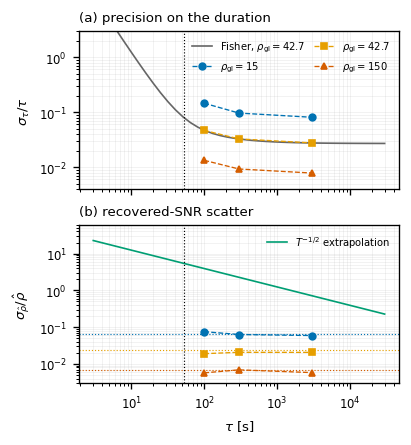

In [8]:
# Column width, two stacked panels: the two claims that matter. sigma_t0 against tau is
# in the table and in the text, and does not need a panel of its own.
fig, axs = plt.subplots(2, 1, figsize=(COL_IN, 3.6), sharex=True)
cols = [C["blue"], C["orange"], C["red"]]
mk = ["o", "s", "^"]
tau_band = 1 / (2 * np.pi * 3e-3)

# (a) fractional precision on tau: improves with duration, collapses once the knee leaves
ax = axs[0]
ax.loglog(tau_scan, fish[:, 2], color=C["grey"], lw=1.0,
          label=r"Fisher, $\rho_{\rm gl}=42.7$")
for j, rho in enumerate(gc.RHOS):
    ax.loglog(gc.TAUS, [R[(i, j)]["sig_tau_frac"] for i in range(3)], mk[j],
              color=cols[j], ms=4, ls="--", lw=0.8, label=rf"$\rho_{{\rm gl}}={rho:g}$")
ax.axvline(tau_band, color="k", lw=0.7, ls=":")
ax.set_ylabel(r"$\sigma_\tau/\tau$")
ax.set_title("(a) precision on the duration", loc="left")
ax.legend(fontsize=6, loc="upper right", ncol=2, columnspacing=1.0)
ax.set_ylim(4e-3, 3)

# (b) recovered-SNR scatter against the 1/sqrt(duration) extrapolation
ax = axs[1]
for j, rho in enumerate(gc.RHOS):
    ax.loglog(gc.TAUS, [R[(i, j)]["rho_scatter"] for i in range(3)], mk[j],
              color=cols[j], ms=4, ls="--", lw=0.8)
    ax.axhline(1 / rho, color=cols[j], lw=0.7, ls=":")
ref = 0.13 * np.sqrt(7 * 86400 / (gc.X99 * tau_scan))     # 13% at one week, ~1/sqrt(T)
ax.loglog(tau_scan, ref, color=C["green"], lw=1.0, label=r"$T^{-1/2}$ extrapolation")
ax.axvline(tau_band, color="k", lw=0.7, ls=":")
ax.set_xlabel(r"$\tau$ [s]"); ax.set_ylabel(r"$\sigma_{\hat\rho}/\hat\rho$")
ax.set_title("(b) recovered-SNR scatter", loc="left")
ax.legend(fontsize=6, loc="upper right")
ax.set_ylim(3e-3, 60)

for a in axs:
    a.grid(alpha=0.3, which="both", lw=0.3)
save(fig, "fig_duration_snr")
plt.show()

Panel (b) is the point. The dotted lines are $1/\rho$; the measured scatter sits on
them, flat in duration. The green curve is what the $\sigma_{\hat\rho} \propto
T^{-1/2}$ scaling of Pozzoli et al. would give if extrapolated from their one-week
anchor down to glitch durations — it exceeds unity below $\tau \sim 10^3\,$s, i.e. it
predicts a recovered SNR consistent with zero, which is the signature of an
extrapolation taken far outside the range it was fitted over (their lever arm is one to
three weeks, a factor of three).

## 6. LaTeX table for `main.tex`

In [9]:
def texnum(x):
    m, e = f"{x:.2e}".split("e")
    return rf"{m}\times10^{{{int(e)}}}"

rows = []
for i in range(3):
    for j in range(3):
        r = R[(i, j)]
        star = r"$^{\star}$" if (r["tau"] == 300.0 and abs(r["rho"] - 42.7) < 1e-6) else ""
        rows.append(rf"${r['tau']:.0f}${star} & ${r['rho']:.4g}$ & ${texnum(r['deltav'])}$ & "
                    rf"${r['sig_t0']:.1f}$ & ${100*r['sig_tau_frac']:.1f}$ & "
                    rf"${100*r['sig_dv_frac']:.1f}$ & ${r['z_std'][2]:.2f}$ & "
                    rf"${100*r['rho_scatter']:.1f}$ \\")
print("\n".join(rows))

$100$ & $15$ & $1.55\times10^{-12}$ & $16.5$ & $14.6$ & $10.6$ & $0.89$ & $7.5$ \\
$100$ & $42.7$ & $4.40\times10^{-12}$ & $5.6$ & $4.7$ & $3.6$ & $0.84$ & $1.9$ \\
$100$ & $150$ & $1.55\times10^{-11}$ & $1.6$ & $1.3$ & $1.0$ & $1.09$ & $0.6$ \\
$300$ & $15$ & $3.51\times10^{-12}$ & $21.6$ & $9.7$ & $10.9$ & $1.10$ & $6.3$ \\
$300$$^{\star}$ & $42.7$ & $1.00\times10^{-11}$ & $7.5$ & $3.3$ & $3.8$ & $0.92$ & $2.1$ \\
$300$ & $150$ & $3.51\times10^{-11}$ & $2.1$ & $0.9$ & $1.1$ & $0.99$ & $0.7$ \\
$3000$ & $15$ & $5.20\times10^{-11}$ & $64.2$ & $8.1$ & $13.1$ & $0.98$ & $5.9$ \\
$3000$ & $42.7$ & $1.48\times10^{-10}$ & $21.2$ & $2.8$ & $4.5$ & $1.00$ & $2.1$ \\
$3000$ & $150$ & $5.20\times10^{-10}$ & $6.0$ & $0.8$ & $1.3$ & $0.84$ & $0.6$ \\


## 7. What goes in the paper

1. $\tau = 300\,$s is at the **94th percentile** of the LPF ordinary-run catalogue.
   Only $\sim6\%$ of catalogued events are longer, and only $\sim8\%$ have their knee
   inside $3\,$mHz at all. The fiducial glitch is a *long* glitch by LPF standards; it
   is short only against an MBHB inspiral, which is the comparison Pozzoli et al. make.
2. At fixed SNR, **duration does not degrade the measurement**. $\sigma_\tau/\tau$
   improves with $\tau$ and saturates; $\sigma_{t_0}$ is minimised near the shortest
   in-band duration and grows sublinearly afterwards. What kills the measurement is
   the knee leaving the band, not shortness per se.
3. Across the whole grid the credible intervals are **calibrated**: $\mathrm{std}(z)$
   is consistent with $1$, so the quoted widths are the realisation scatter.
4. The recovered-SNR scatter is $1/\rho$ and **flat in duration**, so the
   $T^{-1/2}$ growth reported by Pozzoli et al. does not transfer to this analysis.
   Their scaling is a property of a PSD estimated on a signal-length stretch
   contaminated by an unresolved background, over a lever arm of three in duration; the
   caveat that survives is the *background*, not the duration.